In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv('diabetes.csv')

In [2]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [3]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
q1=df.quantile(0.25)
q3=df.quantile(0.75)
iqr=q3-q1
outliers=((df < (q1 -1.25 *iqr)) | (df> (q3 +1.5 * iqr))).sum()
outliers

Pregnancies                  4
Glucose                      6
BloodPressure               46
SkinThickness                1
Insulin                     34
BMI                         19
DiabetesPedigreeFunction    29
Age                          9
Outcome                      0
dtype: int64

In [6]:
for col in df.columns:
    lower=q1[col]- 1.5 *iqr[col]
    upper=q3[col] +1.5 *iqr[col]
    df[col]=df[col].clip(lower,upper)

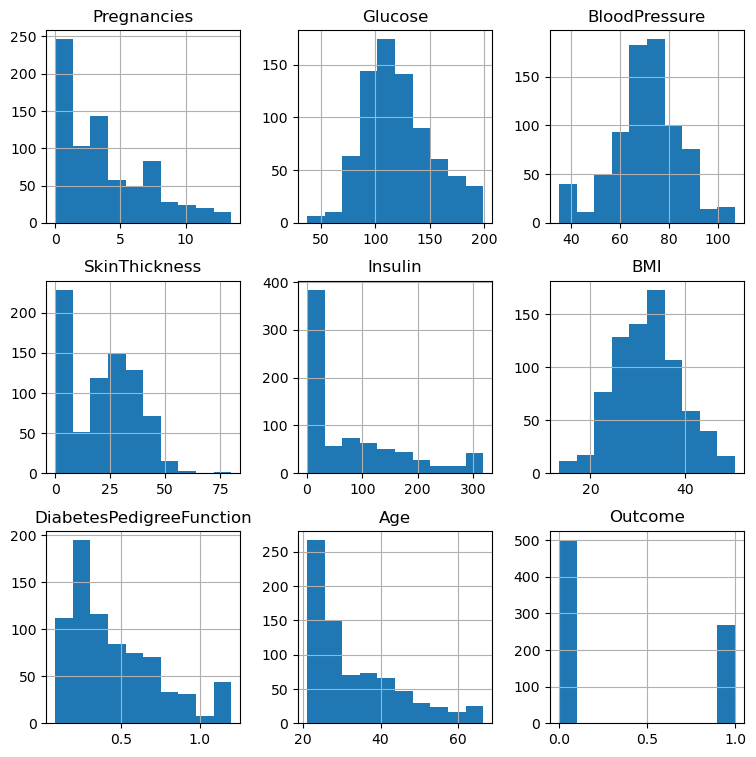

In [16]:
import matplotlib.pyplot as plt
df.hist(figsize=(9,9))
plt.show()

In [10]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [11]:
corr=df.corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128987,0.184307,-0.084349,-0.077793,0.024681,-0.017398,0.549695,0.220392
Glucose,0.128987,1.000000,0.197865,0.059806,0.315856,0.235542,0.120213,0.269056,0.479158
BloodPressure,0.184307,0.197865,1.000000,0.152644,0.050080,0.282544,0.038793,0.304208,0.113301
SkinThickness,-0.084349,0.059806,0.152644,1.000000,0.488101,0.401494,0.177920,-0.119170,0.073125
Insulin,-0.077793,0.315856,0.050080,0.488101,1.000000,0.209665,0.190087,-0.065547,0.124721
BMI,0.024681,0.235542,0.282544,0.401494,0.209665,1.000000,0.141087,0.043375,0.309739
DiabetesPedigreeFunction,-0.017398,0.120213,0.038793,0.177920,0.190087,0.141087,1.000000,0.047289,0.184969
Age,0.549695,0.269056,0.304208,-0.119170,-0.065547,0.043375,0.047289,1.000000,0.242702
Outcome,0.220392,0.479158,0.113301,0.073125,0.124721,0.309739,0.184969,0.242702,1.000000


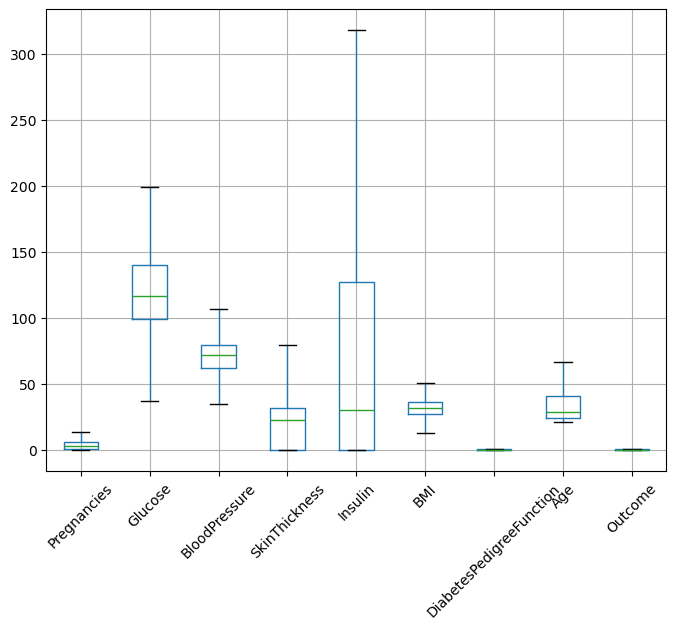

In [15]:
plt.figure(figsize=(8,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

### Glucose (Fasting)

Normal: 70–99 mg/dL

Prediabetes: 100–125 mg/dL

### Diabetes: ≥126 mg/dL

Blood Pressure (Diastolic)

Low: <60 mm Hg

Normal: 60–80 mm Hg

High: >80 mm Hg

### Skin Thickness

Normal Range: 10–50 mm

Indicates subcutaneous fat and body composition

### Insulin (2-Hour)

Normal Range: 16–166 µIU/mL

High values indicate insulin resistance

### Body Mass Index (BMI)

Underweight: <18.5

Normal: 18.5–24.9

Overweight: 25–29.9

Obese: ≥30

### Diabetes Pedigree Function

Range: 0.0–2.5

Higher values indicate stronger genetic risk 


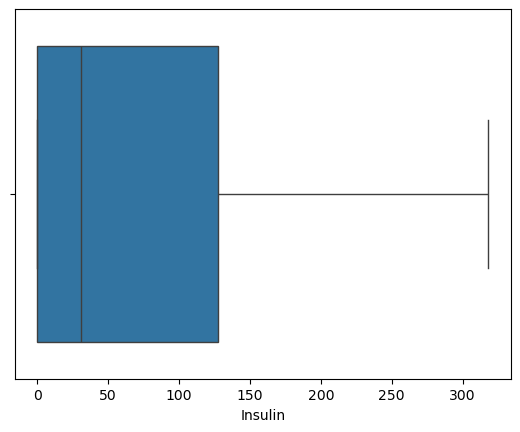

In [19]:
import seaborn as sns
sns.boxplot(x=df['Insulin'])
plt.show()

In [20]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    median = df.loc[df[col] != 0, col].median()
    df.loc[df[col] == 0, col] = median

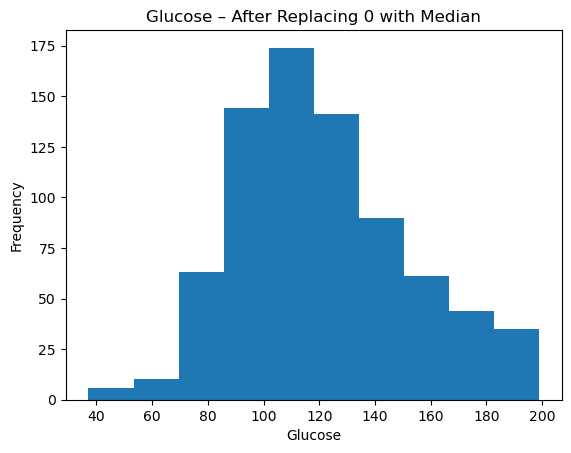

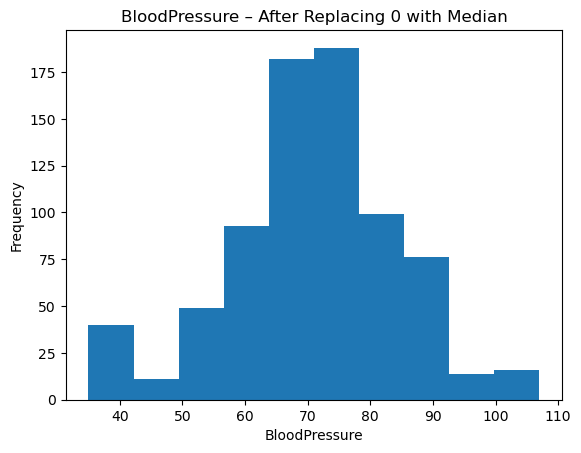

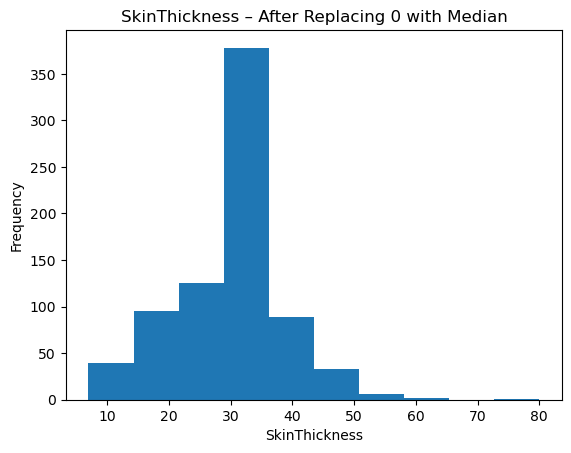

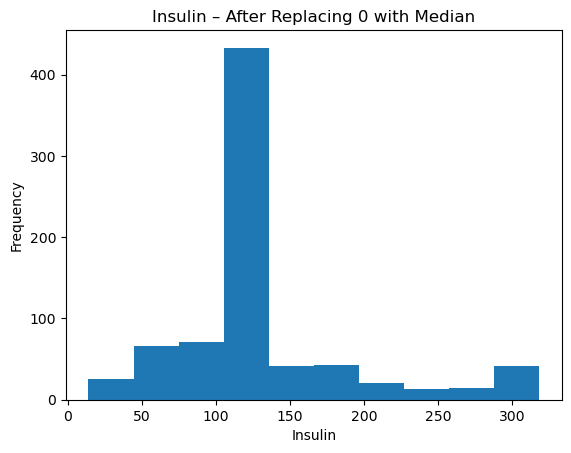

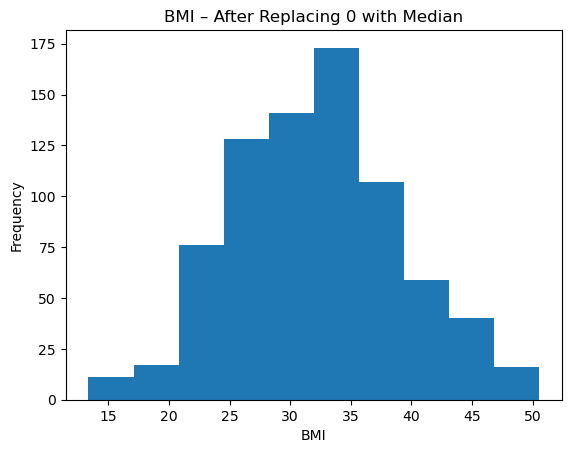

In [22]:
for col in cols:
    plt.figure()
    plt.hist(df[col])
    plt.title(f"{col} – After Replacing 0 with Median")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


In [29]:
grouped_age = df.groupby("Outcome")["Age"].agg(["mean", "min", "max"])
grouped_age

,mean,min,max
Outcome,,,
0,31.135000,21.0,66.5
1,37.052239,21.0,66.5


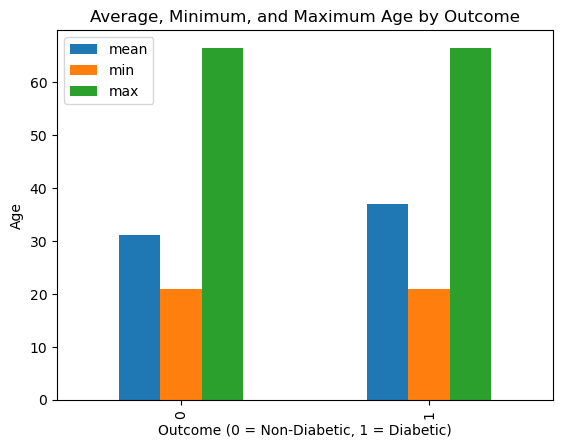

In [30]:
grouped_age.plot(kind="bar")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Age")
plt.title("Average, Minimum, and Maximum Age by Outcome")
plt.show()


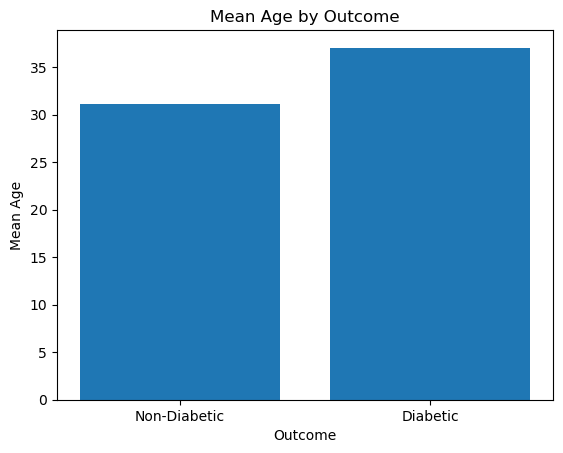

In [31]:
mean_age = df.groupby("Outcome")["Age"].mean()

plt.figure()
plt.bar(mean_age.index, mean_age.values)
plt.xticks([0,1], ["Non-Diabetic", "Diabetic"])
plt.xlabel("Outcome")
plt.ylabel("Mean Age")
plt.title("Mean Age by Outcome")
plt.show()

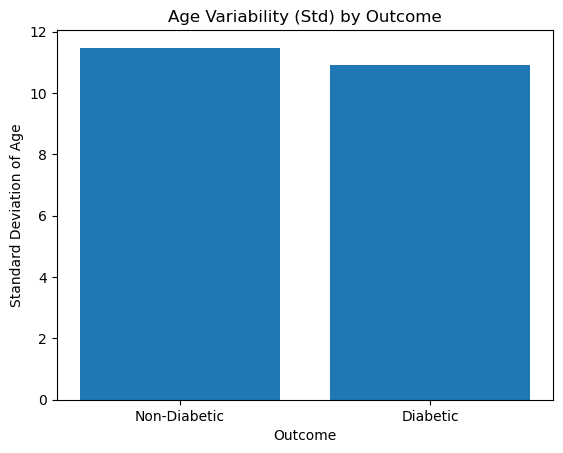

In [32]:
std_age = df.groupby("Outcome")["Age"].std()

plt.figure()
plt.bar(std_age.index, std_age.values)
plt.xticks([0,1], ["Non-Diabetic", "Diabetic"])
plt.xlabel("Outcome")
plt.ylabel("Standard Deviation of Age")
plt.title("Age Variability (Std) by Outcome")
plt.show()


<Axes: xlabel='Age', ylabel='Outcome'>

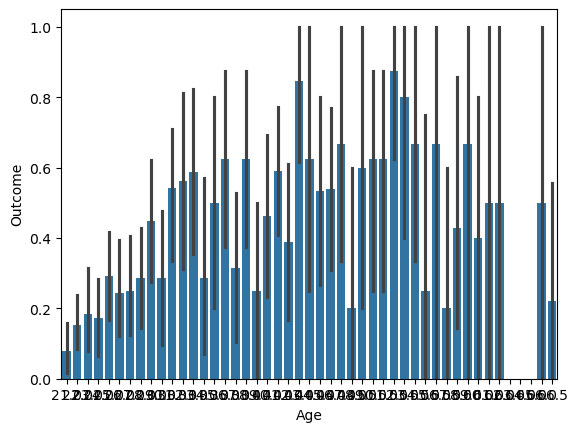

In [33]:
sns.barplot(x=df['Age'],y=df['Outcome'],estimator='mean')

<Axes: xlabel='Age'>

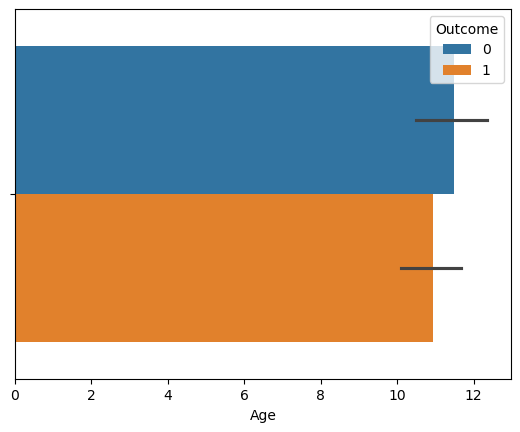

In [35]:
sns.barplot(x=df['Age'],hue=df['Outcome'],estimator='std')

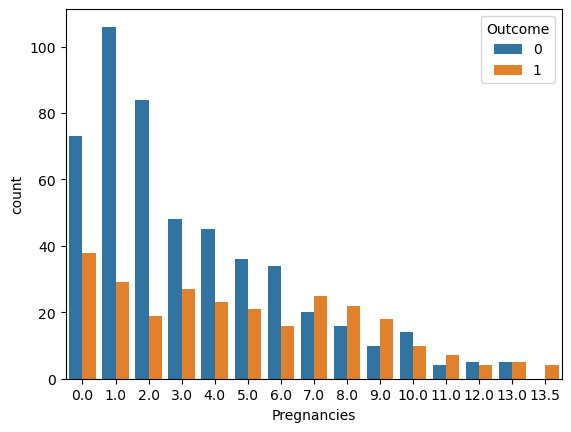

In [37]:
sns.countplot(x='Pregnancies',hue='Outcome',data=df)
plt.show()

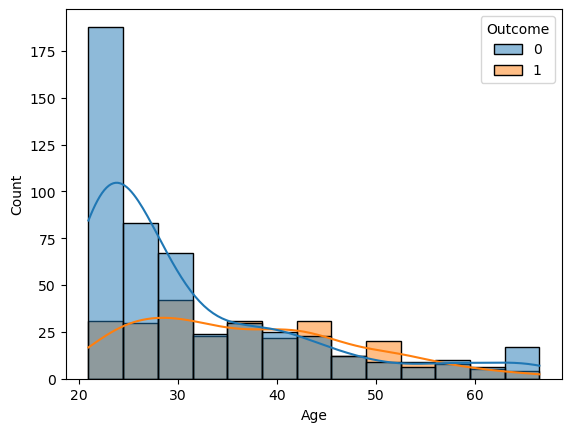

In [36]:
sns.histplot(x='Age',hue='Outcome',data=df,kde=True)
plt.show()

In [38]:
df['Outcome'].value_counts

<bound method IndexOpsMixin.value_counts of 0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64>

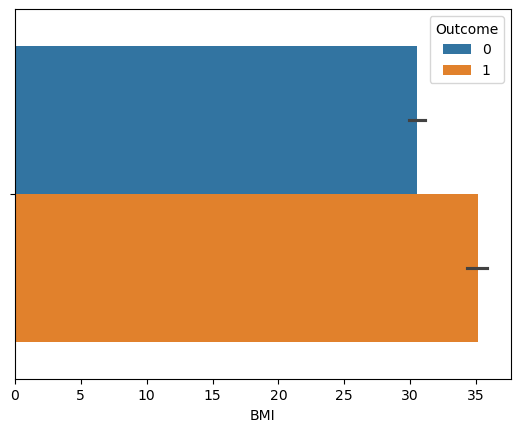

<Axes: xlabel='BMI', ylabel='Count'>

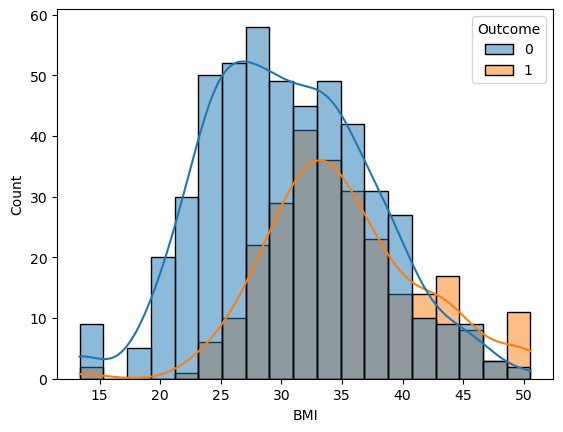

In [40]:
df['BMI'].groupby(df['Outcome']).count()
sns.barplot(x="BMI", hue="Outcome", data=df,estimator="mean")
plt.show()
sns.histplot(x='BMI',hue='Outcome',data=df,kde=True)

Independent t-test for BMI vs Outcome

In [41]:
bmi_diabetic=df["BMI"][df["Outcome"]==1]
bmi_nondiabetic = df["BMI"][df["Outcome"]==0]

In [42]:
from scipy.stats import ttest_ind
stat,p=ttest_ind(bmi_diabetic,bmi_nondiabetic)
alpha=0.05
print("t-statistics:",stat)
print("p-value:",p)

if p < alpha:
    print("Reject H0")
else :
    print("Accepted H0")

t-statistics: 9.015938472681029
p-value: 1.5395912330609838e-18
Reject H0


In [43]:
from scipy.stats import ttest_ind

bp_diabetic = df["BloodPressure"][df["Outcome"] == 1]
bp_nondiabetic = df["BloodPressure"][df["Outcome"] == 0]

stat, p = ttest_ind(bp_diabetic, bp_nondiabetic)

alpha = 0.05
print("BloodPressure t-stat:", stat)
print("BloodPressure p-value:", p)

if p < alpha:
    print("Reject H0")
else:
    print("Accept H0")


BloodPressure t-stat: 3.1561283125115267
BloodPressure p-value: 0.0016613575415501624
Reject H0


In [44]:


cols = ["Pregnancies", "Glucose", "BloodPressure",
        "SkinThickness", "Insulin", "BMI",
        "DiabetesPedigreeFunction", "Age"]

alpha = 0.05

for col in cols:
    group1 = df[col][df["Outcome"] == 1]
    group0 = df[col][df["Outcome"] == 0]

    stat, p = ttest_ind(group1, group0)

    print(f"\nColumn: {col}")
    print("t-statistic:", stat)
    print("p-value:", p)

    if p < alpha:
        print("→ Reject H0 (Significant)")
    else:
        print("→ Accept H0 (Not Significant)")



Column: Pregnancies
t-statistic: 6.253487011630764
p-value: 6.666771475839176e-10
→ Reject H0 (Significant)

Column: Glucose
t-statistic: 15.108904539290883
p-value: 2.4619599112825017e-45
→ Reject H0 (Significant)

Column: BloodPressure
t-statistic: 3.1561283125115267
p-value: 0.0016613575415501624
→ Reject H0 (Significant)

Column: SkinThickness
t-statistic: 6.099971478614843
p-value: 1.6825326732573344e-09
→ Reject H0 (Significant)

Column: Insulin
t-statistic: 6.6722467919417925
p-value: 4.8294023982305416e-11
→ Reject H0 (Significant)

Column: BMI
t-statistic: 9.015938472681029
p-value: 1.5395912330609838e-18
→ Reject H0 (Significant)

Column: DiabetesPedigreeFunction
t-statistic: 5.209210725272575
p-value: 2.439852938745004e-07
→ Reject H0 (Significant)

Column: Age
t-statistic: 6.924215231817787
p-value: 9.284604951584015e-12
→ Reject H0 (Significant)


In [45]:
cols = [
    "Age",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction"
]

In [46]:
# Mean of each feature grouped by Outcome

for col in cols:
    print(f"\nMean of {col} by Outcome")
    print(df.groupby("Outcome")[col].mean())


Mean of Age by Outcome
Outcome
0    31.135000
1    37.052239
Name: Age, dtype: float64

Mean of Glucose by Outcome
Outcome
0    110.202750
1    141.534515
Name: Glucose, dtype: float64

Mean of BloodPressure by Outcome
Outcome
0    69.508000
1    72.880597
Name: BloodPressure, dtype: float64

Mean of SkinThickness by Outcome
Outcome
0    27.726000
1    31.615672
Name: SkinThickness, dtype: float64

Mean of Insulin by Outcome
Outcome
0    124.11375
1    153.94916
Name: Insulin, dtype: float64

Mean of BMI by Outcome
Outcome
0    30.527500
1    35.105597
Name: BMI, dtype: float64

Mean of DiabetesPedigreeFunction by Outcome
Outcome
0    0.420264
1    0.531022
Name: DiabetesPedigreeFunction, dtype: float64


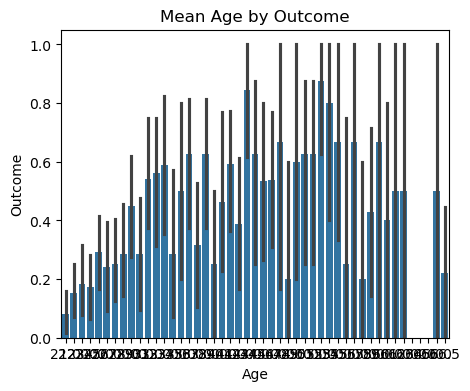

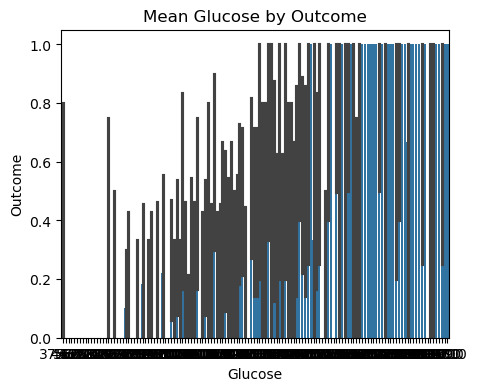

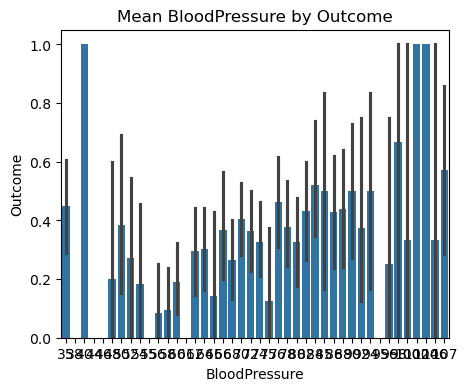

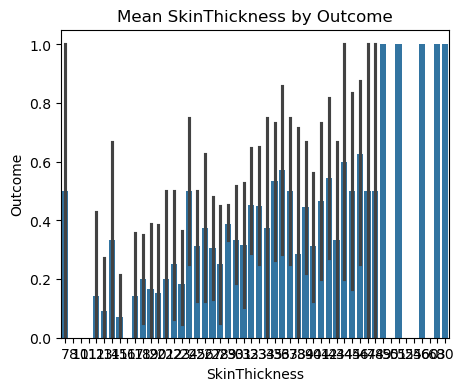

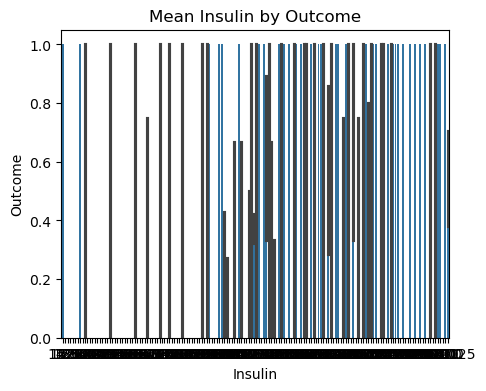

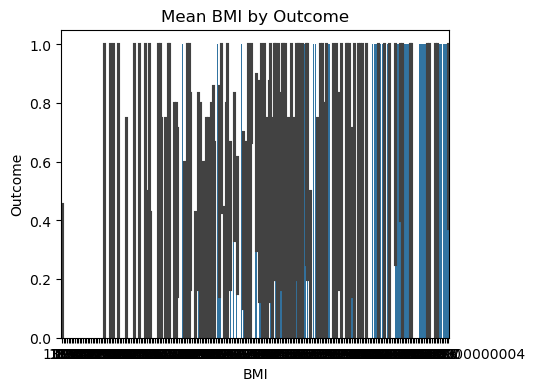

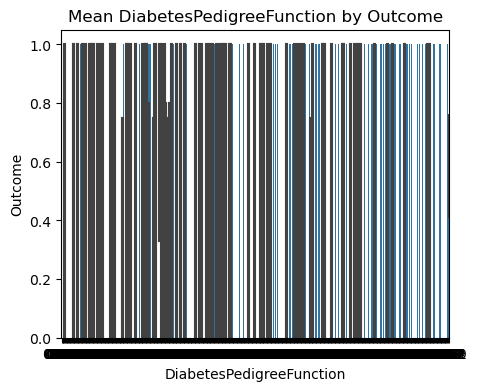

In [47]:
# Barplot – Mean value of feature vs Outcome

import seaborn as sns
import matplotlib.pyplot as plt

for col in cols:
    plt.figure(figsize=(5,4))
    sns.barplot(x=col, y="Outcome", data=df, estimator="mean")
    plt.title(f"Mean {col} by Outcome")
    plt.show()

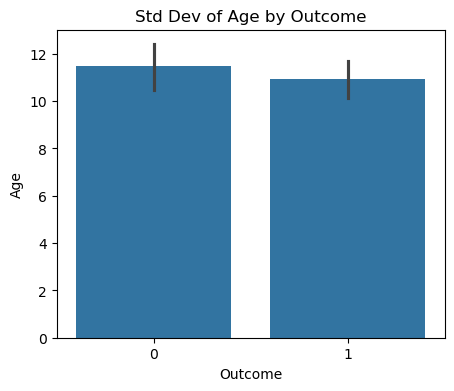

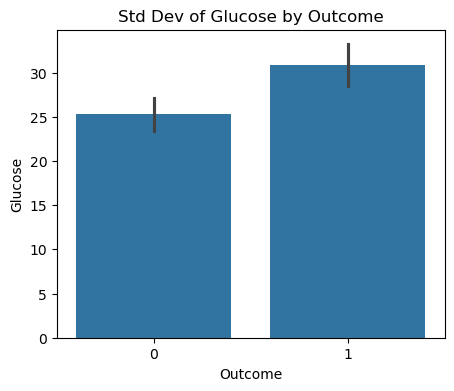

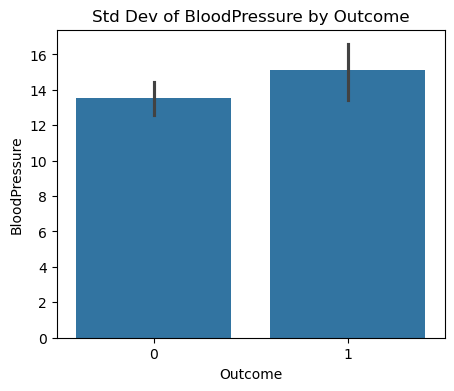

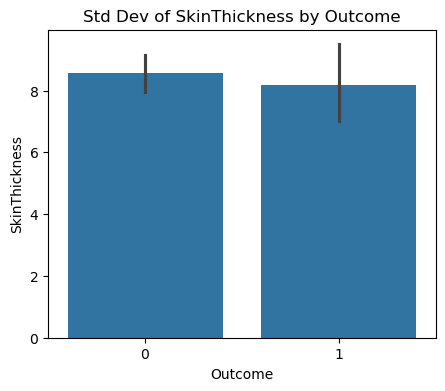

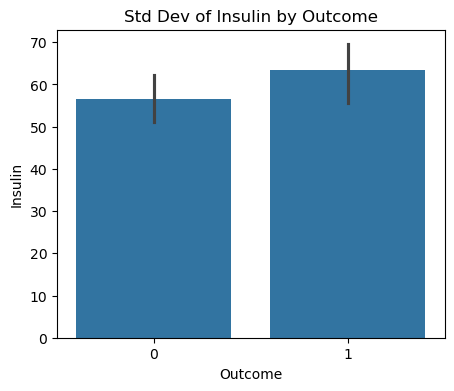

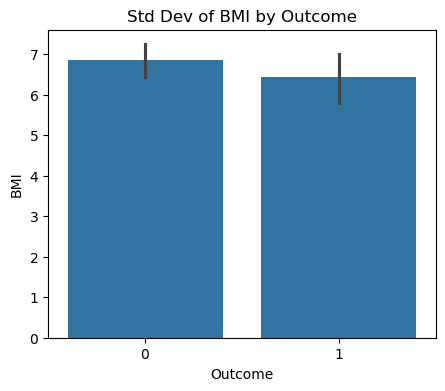

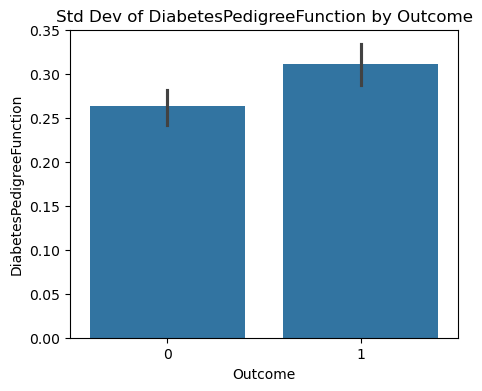

In [48]:
# Barplot – Standard Deviation by Outcome

for col in cols:
    plt.figure(figsize=(5,4))
    sns.barplot(x="Outcome", y=col, data=df, estimator="std")
    plt.title(f"Std Dev of {col} by Outcome")
    plt.show()

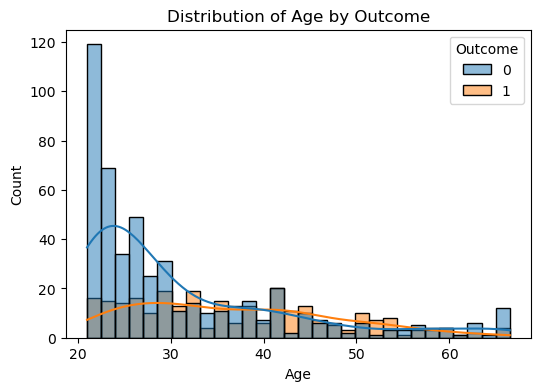

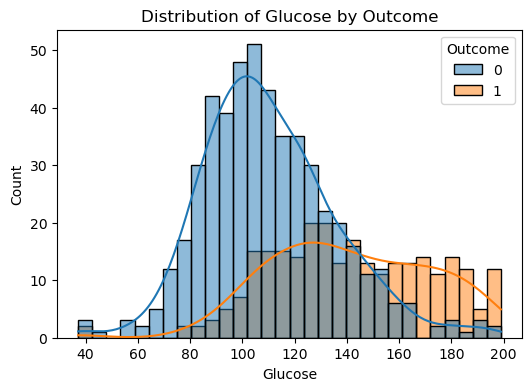

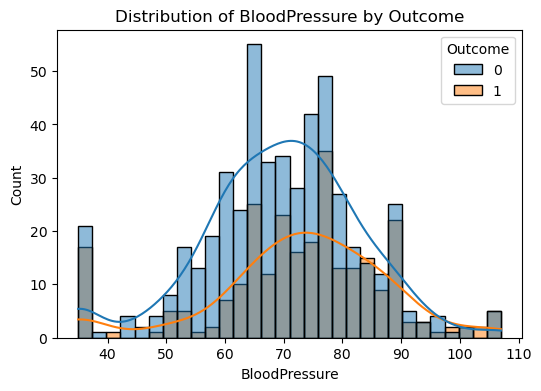

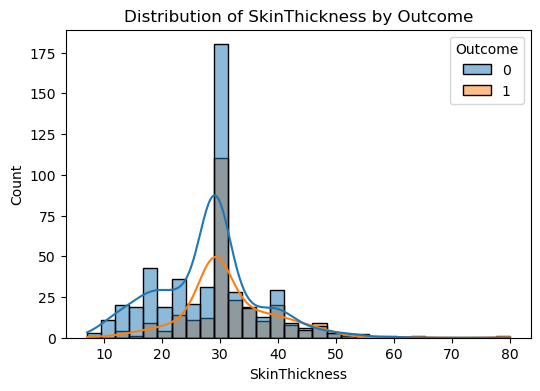

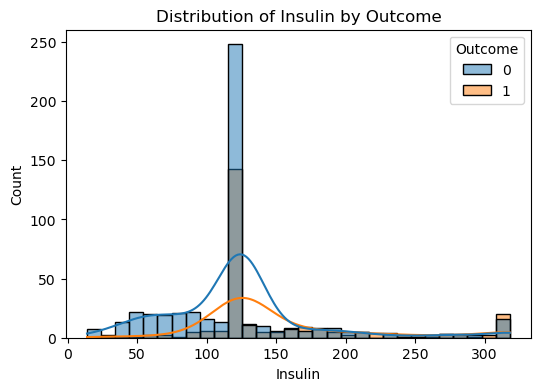

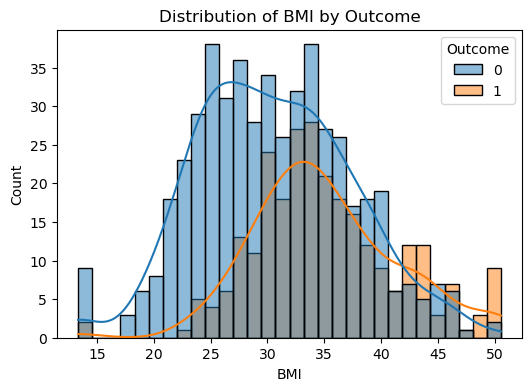

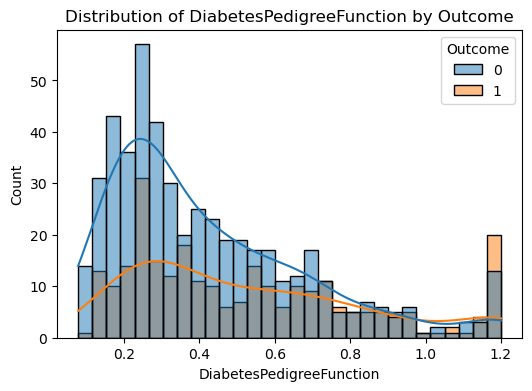

In [49]:
# Histogram + KDE (Distribution comparison)

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="Outcome", kde=True, bins=30)
    plt.title(f"Distribution of {col} by Outcome")
    plt.show()

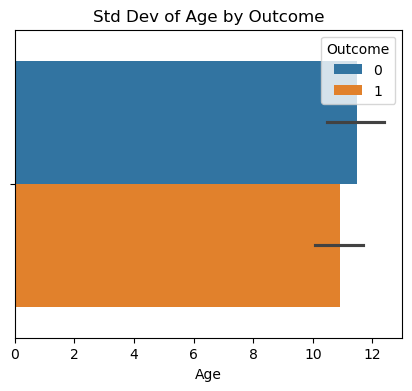

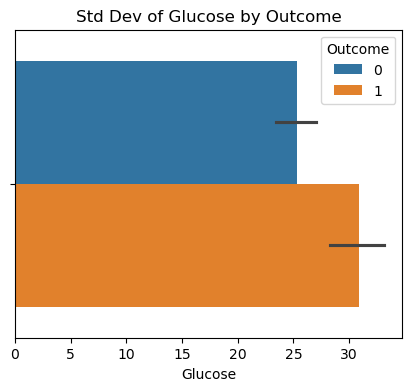

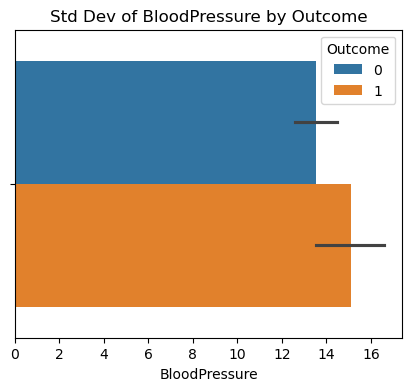

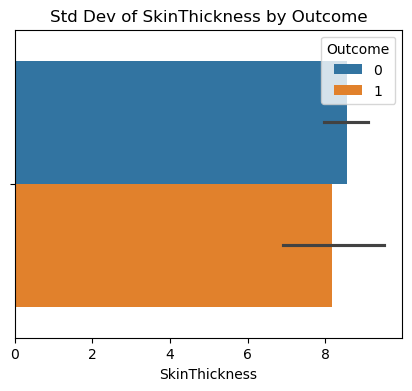

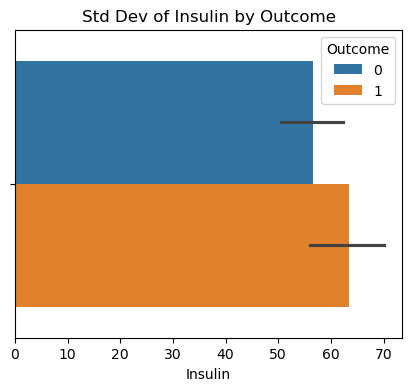

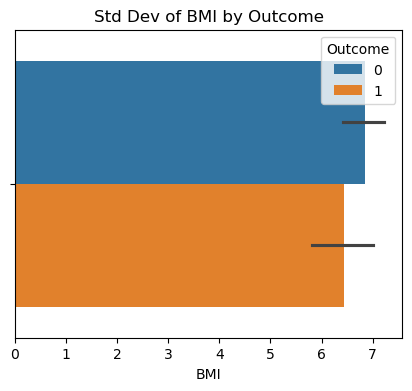

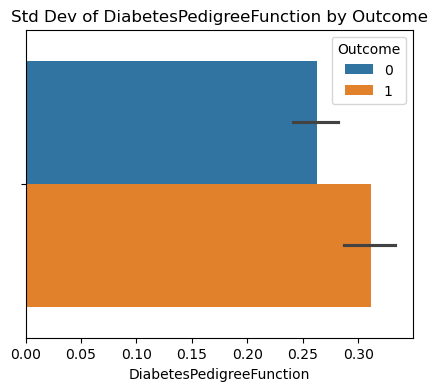

In [51]:
# Barplot – Standard Deviation by Outcome

for col in cols:
    plt.figure(figsize=(5,4))
    sns.barplot(x=df[col],hue=df['Outcome' ],data=df, estimator='std')
    plt.title(f"Std Dev of {col} by Outcome")
    plt.show()

rejecting h0 --> significantly differ from eachother, and this particular column effect the outcome column
Age is dissimilar , Age of the person effect the outcome
Glucose is dissimilar , Glucose of the person effect the outcome
SkinThickness is dissimilar , SkinThickness of the person effect the outcome
Insulin is dissimilar , Insulin of the person effect the outcome
BMI is dissimilar , BMI of the person effect the outcome
DiabetesPedigreeFunction is dissimilar , DiabetesPedigreeFunction of the person effect the outcome

In [52]:
def remove_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return np.clip(df[col], lower, upper)

for col in ["Insulin", "BMI", "DiabetesPedigreeFunction"]:
    df[col] = remove_outliers(col)

In [53]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_scale = [
    "Age",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction"
]

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeGroup
0,6.0,0.684942,0.513889,0.383562,0.527174,0.544355,0.489305,0.637363,1,41-50
1,1.0,0.295753,0.430556,0.301370,0.527174,0.356183,0.243316,0.219780,0,31-40
2,8.0,0.901158,0.402778,0.301370,0.527174,0.267473,0.529412,0.241758,1,31-40
3,1.0,0.320463,0.430556,0.219178,0.000000,0.396505,0.079323,0.000000,0,21-30
4,0.0,0.616988,0.069444,0.383562,1.000000,0.799731,1.000000,0.263736,1,31-40


In [54]:
# Target variable
y = df["Outcome"]

# Feature variables (all except Outcome)
X = df.drop(columns=["Outcome"])

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (768, 9)
y shape: (768,)


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [69]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(X_train,y_train)

ValueError: could not convert string to float: '41-50'

In [71]:
from sklearn.metrics import accuracy_score
y_pred=clf.predict(X_test)
accuracy_score(y_test,y_pred)

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [70]:
y_pred_train=clf.predict(X_train)

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
lr=LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Print the results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ValueError: could not convert string to float: '41-50'